# Load, Subset, and Reproject NISAR GCOV Data with `ISCE3`
<br>

This notebook demonstrates how to load GCOV data with [`ISCE3`](https://github.com/isce-framework/isce3)'s NISAR Product Reader.

<hr>

## Overview

1. [Prerequisites](isce3-prereqs)
2. [Search and download a GCOV product](isce3-search-download)
1. [Load an HDF5 dataset as a `GenericProduct.GCOV` object](isce3-load)
1. [View the `GCOV` metadata](isce3-metadata)
1. [Load a backscatter or covariance image dataset](isce3-image)
1. [Subset the data by index](isce3-subset)
1. [Reproject the data](isce3-reproject)
1. [Calculate statistics and transformations on the data](isce3-stats)
1. [Plot the data](isce3-lot)
1. [Summary](isce3-summary)
1. [Resources and references](isce3-resources)

<hr>

(isce3-prereqs)=
## 1. Prerequisites
| Prerequisite | Importance | Notes |
| --- | --- | --- |
| [The software environment for this cookbook must be installed](https://github.com/ASFOpenSARlab/NISAR_GCOV_Cookbook/blob/main/notebooks/create_software_environment.ipynb) | Necessary | |

- **Rough Notebook Time Estimate**: 3 minutes

<hr>

(isce3-search-download)=
## 2. Search and download a GCOV product

### 2a. Search for GCOV data with asf_search

In [1]:
import os
import asf_search as asf
from datetime import datetime
from getpass import getpass

session = asf.ASFSession()
session.auth_with_creds(input('EDL Username'), getpass('EDL Password'))

start_date = datetime(2025, 11, 22)
end_date = datetime(2025, 12, 5)
area_of_interest = "POLYGON((40.9131 12.3904,41.8891 12.3904,41.8891 13.2454,40.9131 13.2454,40.9131 12.3904))" # POINT or POLYGON as WKT (well-known-text)

opts=asf.ASFSearchOptions(**{
    "maxResults": 250,
    "intersectsWith": area_of_interest,
    "start": start_date,
    "end": end_date,
    "processingLevel": [
        "GCOV"
    ],
    "dataset": [
        "NISAR"
    ],
    "productionConfiguration": [
        "PR"
    ],
    'session': session,
})

response = asf.search(opts=opts)
pattern = r'^(?!.*QA_STATS).*'
hdf5_files = response.find_urls(extension='.h5', pattern=pattern, directAccess=False)
hdf5_files

EDL Username aflewandowski
EDL Password ········


['https://nisar.asf.earthdatacloud.nasa.gov/NISAR/NISAR_L2_GCOV_BETA_V1/NISAR_L2_PR_GCOV_005_172_A_008_2005_DHDH_A_20251122T024618_20251122T024652_X05007_N_F_J_001/NISAR_L2_PR_GCOV_005_172_A_008_2005_DHDH_A_20251122T024618_20251122T024652_X05007_N_F_J_001.h5',
 'https://nisar.asf.earthdatacloud.nasa.gov/NISAR/NISAR_L2_GCOV_BETA_V1/NISAR_L2_PR_GCOV_005_172_A_008_2005_DHDH_A_20251122T024618_20251122T024652_X05009_N_F_J_001/NISAR_L2_PR_GCOV_005_172_A_008_2005_DHDH_A_20251122T024618_20251122T024652_X05009_N_F_J_001.h5',
 'https://nisar.asf.earthdatacloud.nasa.gov/NISAR/NISAR_L2_GCOV_BETA_V1/NISAR_L2_PR_GCOV_006_064_D_082_2005_DHDH_A_20251126T154051_20251126T154125_X05009_N_F_J_001/NISAR_L2_PR_GCOV_006_064_D_082_2005_DHDH_A_20251126T154051_20251126T154125_X05009_N_F_J_001.h5',
 'https://nisar.asf.earthdatacloud.nasa.gov/NISAR/NISAR_L2_GCOV_BETA_V1/NISAR_L2_PR_GCOV_006_165_D_082_2005_SHSH_A_20251203T154910_20251203T154945_X05009_N_F_J_001/NISAR_L2_PR_GCOV_006_165_D_082_2005_SHSH_A_20251203T1

### 2b. Download a GCOV product

In [2]:
from pathlib import Path

data_dir = Path.home() / "GCOV_data"
data_dir.mkdir(exist_ok=True)
print(f'data_dir: {data_dir}')

asf.download_url(hdf5_files[0], data_dir, session=session)

data_dir: /home/jovyan/GCOV_data


<hr>

(isce3-load)=
## 3. Load an HDF5 dataset as a `GenericProduct.GCOV` object

In [3]:
from nisar.products.readers import open_product
from pathlib import Path

data_dir = Path.home() / "GCOV_data"
data_dir.mkdir(exist_ok=True)
gcov_path = list(data_dir.glob("*.h5"))[0]
gcov = open_product(gcov_path) 
gcov

<hr>

(isce3-metadata)=
## 4. View the `GCOV` metadata
 
**The `GCOV` object contains member variables, methods, and additional `ISCE3` objects that all hold product metadata.**

### 4a. View the available `GCOV` member variables.

In [4]:
gcov_member_variables = {
    "CFPath": gcov.CFPath,
    "CalibrationInformationPath": gcov.CalibrationInformationPath,
    "GridPath": gcov.GridPath,
    "IdentificationPath": gcov.IdentificationPath,
    "MetadataPath": gcov.MetadataPath,
    "ProcessingInformationPath": gcov.ProcessingInformationPath,
    "ProductPath": gcov.ProductPath,
    "RootPath": gcov.RootPath,
    "SwathPath": gcov.SwathPath,
    "covarianceTerms": gcov.covarianceTerms,
    "error_channel": gcov.error_channel,
    "filename": gcov.filename,
    "frequencies": gcov.frequencies,
    "identification": gcov.identification,
    "polarizations": gcov.polarizations,
    "productType": gcov.productType,
    "productValidationType": gcov.productValidationType,
    "sarBand": gcov.sarBand,
    "sourceDataPath": gcov.sourceDataPath,
    "sourceDataProcessingInfoPath": gcov.sourceDataProcessingInfoPath,
    "sourceDataSwathsPath": gcov.sourceDataSwathsPath
}
max_len = max(len(v) for v in sorted(gcov_member_variables.keys()))
for k, v in gcov_member_variables.items():
    print(f"{k:{max_len}} {v}")

CFPath                       /
CalibrationInformationPath   /science/LSAR/GCOV/metadata/calibrationInformation
GridPath                     /science/LSAR/GCOV/grids
IdentificationPath           /science/LSAR/identification
MetadataPath                 /science/LSAR/GCOV/metadata
ProcessingInformationPath    /science/LSAR/GCOV/metadata/processingInformation
ProductPath                  /science/LSAR/GCOV
RootPath                     /science/LSAR
SwathPath                    /science/LSAR/GCOV/swaths
covarianceTerms              {'A': ['HHHH', 'HVHV'], 'B': ['HHHH', 'HVHV']}
error_channel                <journal.ext.journal.Error object at 0x7f1663f583b0>
filename                     /home/jovyan/GCOV_data/NISAR_L2_PR_GCOV_005_172_A_008_2005_DHDH_A_20251122T024618_20251122T024652_X05007_N_F_J_001.h5
frequencies                  ['A', 'B']
identification               <nisar.products.readers.Base.Identification.Identification object at 0x7f1662d0d010>
polarizations                {'A': [

### 4b. View the `GCOV` get metadata methods

In [5]:
gcov_metadata_functions = {
    'getCenterFrequency("B")': gcov.getCenterFrequency("B"),
    'getProjectionEpsg()': gcov.getProjectionEpsg(),
    'getGeoGridCoordinateSpacing()': gcov.getGeoGridCoordinateSpacing(),
    'getProductLevel()': gcov.getProductLevel(),
    'getWavelength("B")': gcov.getWavelength("B"),
    
}
max_len = max(len(v) for v in sorted(gcov_metadata_functions.keys()))
for k, v in gcov_metadata_functions.items():
    print(f"{k:{max_len}} {v}")    

getCenterFrequency("B")       1293500000.0
getProjectionEpsg()           32637
getGeoGridCoordinateSpacing() (np.float64(20.0), np.float64(-20.0))
getProductLevel()             L2
getWavelength("B")            0.23176842520293778


### 4c. View the metadata contained in the `GCOV.Identification` object

In [6]:

gcov_identification_member_variables = {
    "absoluteOrbitNumber": gcov.identification.absoluteOrbitNumber,
    "boundingPolygon": gcov.identification.boundingPolygon,
    "diagnosticModeFlag": gcov.identification.diagnosticModeFlag,
    "diagnosticModeName": gcov.identification.diagnosticModeName,
    "isJointObservation": gcov.identification.isJointObservation,
    "isUrgentObservation": gcov.identification.isUrgentObservation,
    "listOfFrequencies": gcov.identification.listOfFrequencies,
    "lookDirection": gcov.identification.lookDirection,
    "missionId": gcov.identification.missionId,
    "orbitPassDirection": gcov.identification.orbitPassDirection,
    "plannedDatatake": gcov.identification.plannedDatatake,
    "plannedObservation": gcov.identification.plannedObservation,
    "productType": gcov.identification.productType,
    "zdEndTime": gcov.identification.zdEndTime,
    "zdStartTime": gcov.identification.zdStartTime
}
max_len = max(len(v) for v in sorted(gcov_identification_member_variables.keys()))
for k, v in gcov_identification_member_variables.items():
    print(f"{k:{max_len}} {v}")    

absoluteOrbitNumber 1655
boundingPolygon     POLYGON ((42.9653462865378 12.0272787738436 557.553526620037,42.9125469070651 12.2351268818557 765.81432984781,42.8683268796226 12.4449791459085 328.23782468113,42.820068404127 12.6539085687136 183.691620620926,42.7723845173458 12.8629850503278 -10.8949919533536,42.7219618086654 13.0714386219549 -10.4608297791094,42.671432807718 13.279881290204 -10.1777782605292,42.6207946546294 13.4883116214118 -9.9108200199742,42.5700437489284 13.696729619245 -9.49880601912043,42.5191825112214 13.9051359236512 -9.21189405386162,42.4682089397571 14.1135294238781 -8.98307611001568,42.2063461277281 14.052262858714 -8.65331268549247,41.9555721128008 13.9932938294166 -8.14497566407234,41.7140941231089 13.9362370503655 -5.93600196159487,41.4774932990126 13.8800728008649 283.703338623258,41.2474607446308 13.8252219493742 632.166014703817,41.0312795196157 13.7734539742824 203.33726444732,40.8188354333047 13.7223734422866 -98.9957114885591,40.6058062701055 13.67094

### 4d. Get the `GCOV` `Orbit` object

In [7]:
orbit = gcov.getOrbit()
orbit

#### View the `Orbit` object member variables

In [8]:
orbit_member_variables = {
    "end_datetime": orbit.end_datetime,
    "end_time": orbit.end_time,
    "mid_datetime": orbit.mid_datetime,
    "mid_time": orbit.mid_time,
    "position": orbit.position,
    "reference_epoch": orbit.reference_epoch,
    "size": orbit.size,
    "spacing": orbit.spacing,
    "start_datetime": orbit.start_datetime,
    "start_time": orbit.start_time,
    "position": orbit.position,
    "velocity": orbit.velocity,
}
max_len = max(len(v) for v in sorted(orbit_member_variables.keys()))
for k, v in orbit_member_variables.items():
    print(f"{k:{max_len}} {v}")    

end_datetime    2025-11-22T02:50:32.000000000
end_time        10232.0
mid_datetime    2025-11-22T02:45:27.000000000
mid_time        9927.0
position        [[ 4.38904655e+06  5.52650260e+06 -1.03279885e+06]
 [ 4.40808924e+06  5.52444811e+06 -9.59565662e+05]
 [ 4.42664601e+06  5.52176152e+06 -8.86226669e+05]
 [ 4.44471386e+06  5.51844383e+06 -8.12789955e+05]
 [ 4.46228990e+06  5.51449607e+06 -7.39263613e+05]
 [ 4.47937124e+06  5.50991937e+06 -6.65655747e+05]
 [ 4.49595508e+06  5.50471493e+06 -5.91974473e+05]
 [ 4.51203867e+06  5.49888402e+06 -5.18227912e+05]
 [ 4.52761931e+06  5.49242797e+06 -4.44424197e+05]
 [ 4.54269437e+06  5.48534821e+06 -3.70571464e+05]
 [ 4.55726126e+06  5.47764623e+06 -2.96677857e+05]
 [ 4.57131747e+06  5.46932359e+06 -2.22751527e+05]
 [ 4.58486052e+06  5.46038191e+06 -1.48800627e+05]
 [ 4.59788803e+06  5.45082291e+06 -7.48333125e+04]
 [ 4.61039763e+06  5.44064836e+06 -8.57744397e+02]
 [ 4.62238705e+06  5.42986012e+06  7.31179167e+04]
 [ 4.63385407e+06  5.41846010

#### View the `Orbit` object methods

In [9]:
orbit_methods = {
    "get_type": orbit.get_type(),
    "get_interp_method": orbit.get_interp_method(),
}
max_len = max(len(v) for v in sorted(orbit_methods.keys()))
for k, v in orbit_methods.items():
    print(f"{k:{max_len}} {v}")

get_type          MOE
get_interp_method OrbitInterpMethod.HERMITE


### 4e. Get the `GCOV`'s `RadarGridParameters` object

In [10]:
radar_grid_param = gcov.getSourceRadarGridParameters("B")
radar_grid_param

#### View the `RadarGridParameters` object's member variables

In [11]:
radar_grid_params = {
    "az_time_interval": radar_grid_param.az_time_interval,
    "end_range": radar_grid_param.end_range,
    "length": radar_grid_param.length,
    "lookside": radar_grid_param.lookside,
    "mid_range": radar_grid_param.mid_range,
    "prf": radar_grid_param.prf,
    "range_pixel_spacing": radar_grid_param.range_pixel_spacing,
    "ref_epoch": radar_grid_param.ref_epoch,
    "sensing_datetime()": radar_grid_param.sensing_datetime(),
    "sensing_mid": radar_grid_param.sensing_mid,
    "sensing_start": radar_grid_param.sensing_start,
    "sensing_stop": radar_grid_param.sensing_stop,
    "shape": radar_grid_param.shape,
    "size": radar_grid_param.size,
    "starting_range": radar_grid_param.starting_range,
    "wavelength": radar_grid_param.wavelength,
    "width": radar_grid_param.width,
}
max_len = max(len(v) for v in sorted(radar_grid_params.keys()))
for k, v in radar_grid_params.items():
    print(f"{k:{max_len}} {v}")    

az_time_interval    0.0006578947368421052
end_range           1047324.952023
length              53200
lookside            LookSide.Left
mid_range           965044.4136544167
prf                 1520.0
range_pixel_spacing 24.982704833333333
ref_epoch           2025-11-22T00:00:00.000000000
sensing_datetime()  2025-11-22T02:46:18.000000000
sensing_mid         9995.499671052632
sensing_start       9978.0
sensing_stop        10012.999342105262
shape               (53200, 6588)
size                350481600
starting_range      882763.8752858334
wavelength          0.23176842520293778
width               6588


### 4f. Get the `GCOV`'s  `GeoGridParameters` object

In [12]:
geo_grid_param = gcov.getGeoGridParameters("B", "HHHH")
geo_grid_param

#### View the `GeoGridParameters` object's member variables

In [13]:
geo_grid_params = {
    "end_y": geo_grid_param.end_y,
    "end_x": geo_grid_param.end_x,
    "epsg":geo_grid_param.epsg,
    "length": geo_grid_param.length,
    "spacing_x": geo_grid_param.spacing_x,
    "spacing_y": geo_grid_param.spacing_y,
    "start_x": geo_grid_param.start_x,
    "start_y": geo_grid_param.start_y,
    "width": geo_grid_param.width
}
max_len = max(len(v) for v in sorted(geo_grid_params.keys()))
for k, v in geo_grid_params.items():
    print(f"{k:{max_len}} {v}")   

end_y     1254240.0
end_x     945360.0
epsg      32637
length    4176
spacing_x 80.0
spacing_y -80.0
start_x   604080.0
start_y   1588320.0
width     4266


<hr>

(isce3-image)=
## 5. Load a backscatter or covariance image dataset

In [14]:
hh_backscatter_power = gcov.getImageDataset(frequency='B', polarization='HHHH')
hh_backscatter_power

<HDF5 dataset "HHHH": shape (4176, 4266), type "<f4">

<hr>

(isce3-subset)=
## 6. Subset the data by index

In [15]:
hh_subset = hh_backscatter_power[2000:2500, 2000:2500]
print(f"hh_subset.shape: {hh_subset.shape}")
hh_subset

hh_subset.shape: (500, 500)


array([[0.00939524, 0.00927985, 0.00995409, ..., 0.14159203, 0.20648956,
        0.15859222],
       [0.00784624, 0.00982141, 0.00932574, ..., 0.16281128, 0.27650452,
        0.23508835],
       [0.00944102, 0.00740898, 0.01048076, ..., 0.2080822 , 0.18525505,
        0.0991888 ],
       ...,
       [0.18820381, 0.20445824, 0.23353004, ..., 0.21840286, 0.23962021,
        0.21183014],
       [0.21182442, 0.20775032, 0.21692657, ..., 0.18688774, 0.2677307 ,
        0.30571747],
       [0.19470596, 0.26195145, 0.20456696, ..., 0.20847893, 0.22146416,
        0.30142975]], shape=(500, 500), dtype=float32)

<hr>

(isce3-reproject)=
## 7. Reproject the data

There are multiple ways to reproject the data. `GCOV` objects do not have a reprogection method, so you will need to use other tools. This example uses `xarray` and `rioxarray`.

In [16]:
import xarray as xr
import rioxarray

# Load the image layer in an xarray.DataArray
da = xr.DataArray(
    hh_backscatter_power[...],
    dims=("y", "x"),
    name="HHHH",
)

# Add spatial coords to the DataArray
x_coords, y_coords = gcov.getGeoGridCoordinateDatasets("B")
da = da.assign_coords(y=("y", y_coords), x=("x", x_coords))

# Add the current CRS to the DataArray
epsg = gcov.getProjectionEpsg()
da = da.rio.write_crs(f"EPSG:{epsg}", inplace=True)

# Set the y and x coords as spatial dimensions
da = da.rio.set_spatial_dims(x_dim="x", y_dim="y", inplace=True)

# reproject the data
da_reproj = da.rio.reproject("EPSG:4326", inplace=True)
hh_reproj_subset = da_reproj[2000:2500, 2000:2500]
hh_reproj_subset

<xarray.DataArray 'HHHH' (y: 500, x: 500)> Size: 1MB
array([[0.00912082, 0.00986767, 0.00876832, ..., 0.12249756, 0.16461945,
        0.09686947],
       [0.01166916, 0.00836504, 0.00940132, ..., 0.1437149 , 0.18369293,
        0.19124603],
       [0.01050782, 0.01002836, 0.00910902, ..., 0.15548515, 0.11304855,
        0.17221832],
       ...,
       [0.09050751, 0.12984276, 0.14422607, ..., 0.1967125 , 0.2253151 ,
        0.2075119 ],
       [0.15025711, 0.18939781, 0.08669186, ..., 0.29886246, 0.27486038,
        0.22723961],
       [0.10423946, 0.08032131, 0.08684921, ..., 0.2321415 , 0.20028305,
        0.23788643]], shape=(500, 500), dtype=float32)
Coordinates:
  * y            (y) float64 4kB 12.91 12.9 12.9 12.9 ... 12.54 12.54 12.54
  * x            (x) float64 4kB 41.41 41.41 41.41 41.42 ... 41.78 41.78 41.78
    spatial_ref  int64 8B 0
Attributes:
    _FillValue:  nan

In [17]:
hh_reproj_subset.spatial_ref.attrs

{'crs_wkt': 'GEOGCS["WGS 84",DATUM["WGS_1984",SPHEROID["WGS 84",6378137,298.257223563,AUTHORITY["EPSG","7030"]],AUTHORITY["EPSG","6326"]],PRIMEM["Greenwich",0,AUTHORITY["EPSG","8901"]],UNIT["degree",0.0174532925199433,AUTHORITY["EPSG","9122"]],AXIS["Latitude",NORTH],AXIS["Longitude",EAST],AUTHORITY["EPSG","4326"]]',
 'semi_major_axis': 6378137.0,
 'semi_minor_axis': 6356752.314245179,
 'inverse_flattening': 298.257223563,
 'reference_ellipsoid_name': 'WGS 84',
 'longitude_of_prime_meridian': 0.0,
 'prime_meridian_name': 'Greenwich',
 'geographic_crs_name': 'WGS 84',
 'horizontal_datum_name': 'World Geodetic System 1984',
 'grid_mapping_name': 'latitude_longitude',
 'spatial_ref': 'GEOGCS["WGS 84",DATUM["WGS_1984",SPHEROID["WGS 84",6378137,298.257223563,AUTHORITY["EPSG","7030"]],AUTHORITY["EPSG","6326"]],PRIMEM["Greenwich",0,AUTHORITY["EPSG","8901"]],UNIT["degree",0.0174532925199433,AUTHORITY["EPSG","9122"]],AXIS["Latitude",NORTH],AXIS["Longitude",EAST],AUTHORITY["EPSG","4326"]]',
 'Geo

<hr>

(isce3-stats)=
## 7. Calculate statistics and transformations on the data

### As a loaded HDF5 dataset, you can call many `numpy` functions directly on the data.

In [18]:
import numpy as np

print(f"min: {np.nanmin(hh_backscatter_power)}")
print(f"max: {np.nanmax(hh_backscatter_power)}")
print(f"mean: {np.nanmean(hh_backscatter_power)}")

min: 6.742128150260054e-17
max: 127.455078125
mean: 0.12399619817733765


### Note that some `numpy` functions and attributes are not available with the loaded HDF5 dataset

For example, the code cell below will raise an `AttributeError` when trying to view the `T` (transpose attribute)

In [19]:
hh_backscatter_power.T

AttributeError: 'Dataset' object has no attribute 'T'

### To view the `T` attribute, you must first read the data into memory as a `numpy.ndarray`

You can trigger the data to be read into memory by indexing the entire dataset with `[...]`:

`hh_backscatter_power.T` -> `hh_backscatter_power[...].T`

In [20]:
print(f"hh_backscatter_power.shape: {hh_backscatter_power.shape}")
print(f"hh_backscatter_power[...].T.shape: {hh_backscatter_power[...].T.shape}\n")

hh_backscatter_power[...].T

hh_backscatter_power.shape: (4176, 4266)
hh_backscatter_power[...].T.shape: (4266, 4176)



array([[nan, nan, nan, ..., nan, nan, nan],
       [nan, nan, nan, ..., nan, nan, nan],
       [nan, nan, nan, ..., nan, nan, nan],
       ...,
       [nan, nan, nan, ..., nan, nan, nan],
       [nan, nan, nan, ..., nan, nan, nan],
       [nan, nan, nan, ..., nan, nan, nan]],
      shape=(4266, 4176), dtype=float32)

<hr>

(isce3-plot)=
## 8. Plot the data

### Convert the data from linear scale (power) to logarithmic scale (dB) for visualization

In [21]:
hh_backscatter_dB = 10 * np.log10(hh_backscatter_power)

### Plot the image data in dB

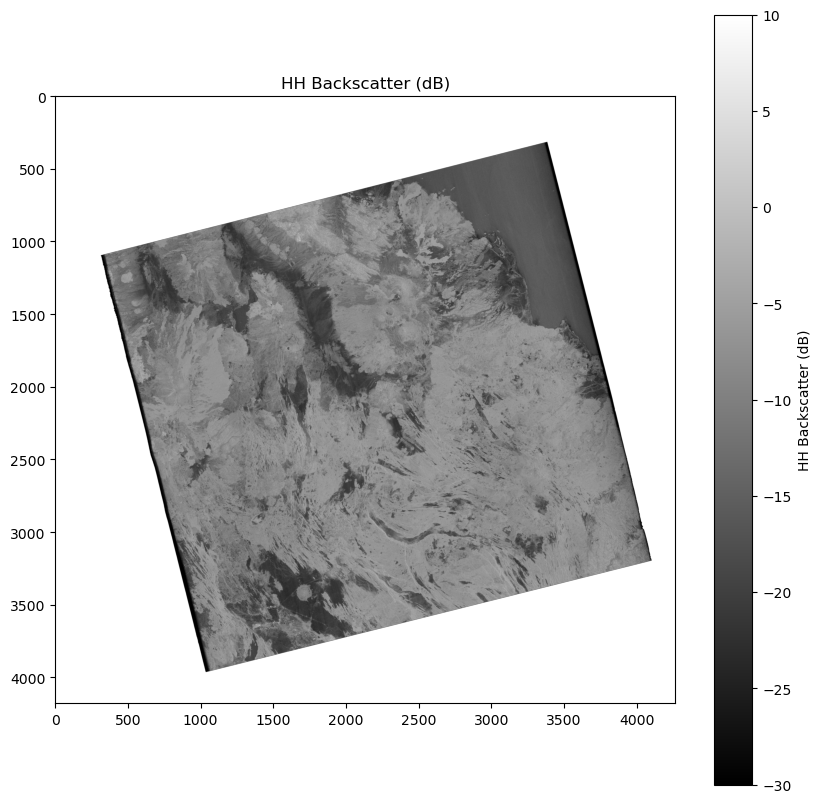

In [22]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 10))
plt.imshow(hh_backscatter_dB, cmap="gray", vmin=-30.0, vmax=10.0)
plt.colorbar(label="HH Backscatter (dB)")
plt.title("HH Backscatter (dB)")
plt.show()

<hr>

(isce3-summary)=
## 4. Summary

You have now run an example that loads NISAR GCOV data with `isce3`, accesses its metadata, creates a subset, reprojects the data, and plots an image layer.
<hr>

(isce3-resources)=
## 6. Resources and references
- [isce3](https://github.com/isce-framework/isce3)

**Author:** Alex Lewandowski